# Ноутбук с анализом ошибок

## 1. Импорт бибилиотек и конфигурация проекта

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.linear_model import Ridge
from category_encoders.cat_boost import CatBoostEncoder
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import GridSearchCV, KFold, RandomizedSearchCV
import copy
from sklearn.model_selection import cross_val_score
import optuna
from sklearn.model_selection import cross_validate
import xgboost as xgb
import pyarrow
import phik
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
import catboost
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
    plot_parallel_coordinate
)
from catboost import CatBoostRegressor
import mlflow.sklearn
from phik.report import plot_correlation_matrix
import plotly
import mlflow
import time
from scipy.stats import randint, uniform, loguniform
import os
from datetime import datetime
import category_encoders as ce
import joblib
from sklearn.inspection import PartialDependenceDisplay
import shap
from catboost import Pool

c:\Users\Степан\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Создадим словарь конфигураций.

CONFIG = {
    # Константы
    "DEV_MODE": False,
    "DEV_SAMPLE_SIZE": 100000,
    "RANDOM_STATE": 42,
    # Целевая переменная 
    "TARGET": "Цена",
    "YEAR": datetime.now().year
}

In [3]:
train = pd.read_parquet("../data/optimized/train_optimized.parquet")
test = pd.read_parquet("../data/optimized/test_optimized.parquet")
X_train = train.drop(columns=[CONFIG["TARGET"]])
y_train = train[CONFIG["TARGET"]]
X_test = test.drop(columns=[CONFIG["TARGET"]])
y_test = test[CONFIG["TARGET"]]

dir = 'C:/project/car-price-analyzer/src/mlflow_runs'
os.makedirs(dir, exist_ok=True)
mlflow.set_tracking_uri(f'sqlite:///{dir}/mlflow.db')
mlflow.set_experiment('error_analysis')

2026/08/05 22:43:30 INFO mlflow.tracking.fluent: Experiment with name 'error_analysis' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:c:/project/car-price-analyzer/researches/mlruns/8', creation_time=1785959010671, effective_trace_archival_retention=None, experiment_id='8', last_update_time=1785959010671, lifecycle_stage='active', name='error_analysis', tags={}, trace_location=None, workspace='default'>

In [19]:
model = joblib.load('../models/best_catboost_model.pkl')

## 2. Анализ ошибок

In [39]:
pd.options.display.float_format = "{:,.2f}".format
pd.set_option("display.expand_frame_repr", False)
y_pred_test = model.predict(X_test)
df = X_test.copy()
df['Настоящая цена'] = y_test
df['Предсказанная цена'] = y_pred_test
df['Ошибка'] = df['Настоящая цена'] - df['Предсказанная цена']
df['Абсолютная ошибка'] = abs(df['Настоящая цена'] - df['Предсказанная цена'])
df['Относительная ошибка в %'] = (df['Абсолютная ошибка'] / df['Настоящая цена']) * 100

In [43]:
top_worst = df.sort_values(by='Относительная ошибка в %', ascending=False).head(50)
df['Ценовые сегменты'] = pd.qcut(df['Настоящая цена'], q=5, labels=['Очень низкий', 'Низкий', 'Средний', 'Высокий', 'Люкс'])
price_segment_errors = df.groupby('Ценовые сегменты').agg(
    mape=('Относительная ошибка в %', 'mean'), mean_bias=("Ошибка", "mean")
)

C:\Users\Степан\AppData\Local\Temp\ipykernel_22272\1204631705.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_segment_errors = df.groupby('Ценовые сегменты').agg(


In [53]:
df['Возраст'] = df['Год размещения'] - df['Год']
bins = [-1, 3, 10, np.inf]
labels = ["0–3 года (Свежие)", "4–10 лет (Средние)", "10+ лет (Старые)"]
df['Возрастная группа'] = pd.cut(df['Возраст'], bins=bins, labels=labels)
age_errors = df.groupby('Возрастная группа',observed=False).agg(
    mape=('Относительная ошибка в %', 'mean'), mean_bias=("Ошибка", "mean"), median_abs_err=('Абсолютная ошибка', 'median'), count=('Настоящая цена', 'count')
    ).reset_index()
print(age_errors)

    Возрастная группа  mape  mean_bias  median_abs_err  count
0   0–3 года (Свежие) 10.18  95,115.24      160,294.05   4033
1  4–10 лет (Средние) 11.25  13,987.94      125,242.69  22222
2    10+ лет (Старые) 16.81  11,815.86       66,139.50  79783


In [45]:
print("10 худших объявлений")
print(top_worst[["Марка", "Модель", "Год", "Настоящая цена", "Предсказанная цена", "Относительная ошибка в %"]])

10 худших объявлений
                Марка              Модель      Год  Настоящая цена  Предсказанная цена  Относительная ошибка в %
97466      volkswagen              Tiguan 2,018.00      187,000.00        2,024,679.36                    982.72
75367           lexus               GX460 2,020.00      650,000.00        5,652,454.86                    769.61
31974           geely             Coolray 2,022.00      330,000.00        1,496,170.62                    353.39
6325           toyota          Hilux Surf 1,993.00      200,000.00          854,041.07                    327.02
42817          toyota               Camry 2,008.00      190,000.00          750,453.22                    294.98
27104      volkswagen                Polo 2,018.00      160,000.00          628,735.28                    292.96
8052          hyundai            Grandeur 2,015.00      350,000.00        1,289,437.92                    268.41
6459            lexus               GS300 2,005.00      200,000.00         

In [44]:
print('Ошибки по ценовым сегментам')
print(price_segment_errors)

Ошибки по ценовым сегментам
                  mape  mean_bias
Ценовые сегменты                 
Очень низкий     22.86 -29,622.95
Низкий           17.16  -2,689.20
Средний          14.15  -1,267.27
Высокий          11.92  16,238.06
Люкс             10.75  95,800.00


(0.0, 25000000.0)

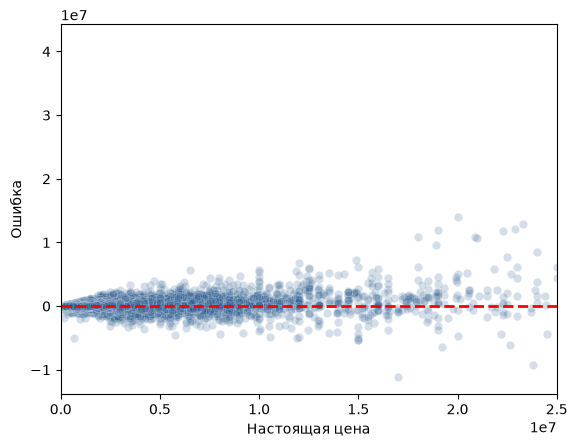

In [68]:
sns.scatterplot(
    data=df,
    x="Настоящая цена",
    y="Ошибка",
    alpha=0.2,
    color="#2b5c8f",
)

plt.axhline(
    0, color="red", linestyle="--", linewidth=2, label="Нулевая ошибка"
)
plt.xlim(0, 25_000_000)

На основе проведенного анализа ошибок (Error Analysis) выявлено, что все отклонения предсказаний модели делятся на три основные категории, для каждой из которых сформулированы инженерные и продуктовые гипотезы.

Категория 1: Шум в целевой переменной
Детальный разбор Топ-50 наибольших ошибок (MAPE > 300%) показал, что модель не ошиблась, а предсказала адекватную рыночную стоимость. Ошибка возникла из-за манипуляций авторов объявлений (указание суммы первого взноса по кредиту, завлекающие цены автосалонов, нерастаможенные авто или другие причины).
Категория 2: Отсутствие фичей реального состояния
Высокий процентный разброс ошибок на автомобилях старше 10 лет объясняется тем, что для старых авто определяющим фактором является физическое состояние, а не год выпуска или пробег.
Категория 3: Дизбаланс выборки и эффект «регрессии к среднему»
На авто стоимостью от 15 млн руб. модель систематически занижает цену (Ошибка > 0), так как премиум-сегмент составляет менее 2% от всей обучающей выборки (всего ~4 000 авто возрастом 0–3 года против ~80 000 старых авто).

Главные выводы:
1. Фейковые цены в датасете: Топ-ошибки (MAPE > 300%) возникли из-за объявлений с нереальными ценами. Модель предсказала адекватную рыночную цену.
2. Смещение в Люкс-сегменте: Из-за дисбаланса данных (премиум-авто меньше 2%) модель консервативна и занижает цены на авто дороже 15 млн ₽.
3. Индикатор уверенности: Для редких автомобилей или машин старше 15 лет UX должен выводить не точечную цену, а диапазон, честно информируя пользователя о высоком разбросе рынка в этом сегменте.